# Newton-Raphson metode for polynom med deg > 2.
ref: https://mathworld.wolfram.com/NewtonsMethod.html

enkel rot: https://math.stackexchange.com/questions/3136446/condition-for-convergence-of-newton-raphson-method

## 1.tildelt funksjon og nullpunkter

In [ ]:
import hashlib
import unicodedata

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def normalize_name(name):
    """Gjør små navnevariasjoner irrelevante for funksjonstildelingen."""
    name = unicodedata.normalize("NFKD", name.strip().casefold())
    name = "".join(char for char in name
                   if not unicodedata.combining(char))
    return " ".join(name.split())


def function_id(first_name, number_of_functions):
    """Gjør fornavnet om til en stabil indeks i funksjonspuljen."""
    normalized = normalize_name(first_name)
    text = f"IMAX3011-newton-2026:{normalized}"
    digest = hashlib.sha256(text.encode("utf-8")).digest()
    return int.from_bytes(digest[:8], byteorder="big") % number_of_functions


FUNCTIONS = [
    {"label": "A", "coefficients": [1, 0, 0, -1],
     "formula": "z³ − 1", "plot_window": (-2, 2, -2, 2)},
    {"label": "B", "coefficients": [1, -2j, -1, 2j],
     "formula": "(z − 1)(z + 1)(z − 2i)",
     "plot_window": (-2.5, 2.5, -2, 3)},
    {"label": "C", "coefficients": [1, 0, -2, -4],
     "formula": "(z − 2)(z + 1 − i)(z + 1 + i)",
     "plot_window": (-3, 3, -3, 3)},
    {"label": "D", "coefficients": [1, 0, 0, 0, -1],
     "formula": "z⁴ − 1", "plot_window": (-2, 2, -2, 2)},
    {"label": "E", "coefficients": [1, 0, -3.75, 0, -1],
     "formula": "(z − 2)(z + 2)(z − 0.5i)(z + 0.5i)",
     "plot_window": (-3, 3, -2.5, 2.5)},
    {"label": "F", "coefficients": [1, 0, 0, 1, 1],
     "formula": "z⁴ + z + 1", "plot_window": (-2.5, 2.5, -2.5, 2.5)},
    {"label": "G", "coefficients": [1, 0, 0, 0, 0, -1],
     "formula": "z⁵ − 1", "plot_window": (-2, 2, -2, 2)},
    {"label": "H", "coefficients": [1, -1.5, -0.5, -0.5, -1.5, 1],
     "formula": "(z − 2)(z + 1)(z − 0.5)(z − i)(z + i)",
     "plot_window": (-2.5, 2.5, -2.5, 2.5)},
    {"label": "I", "coefficients": [1, 0, 0, 0, -1, 1],
     "formula": "z⁵ − z + 1", "plot_window": (-2.5, 2.5, -2.5, 2.5)},
]


def prepare_function(entry):
    """Lag f, f', nullpunkter og kritiske punkter fra én tabellrad.

    Denne funksjonen gjør oppsettet for oss. I forsøkene nedenfor arbeider vi
    med f og df, og trenger vanligvis ikke å endre selve funksjonen her.
    """
    coefficients = np.asarray(entry["coefficients"], dtype=complex)
    derivative_coefficients = np.polyder(coefficients)
    roots = np.roots(coefficients)
    critical_points = np.roots(derivative_coefficients)

    def f(z):
        return np.polyval(coefficients, z)

    def df(z):
        return np.polyval(derivative_coefficients, z)

    return f, df, roots, critical_points


# Bytt teksten med ditt eget fornavn.
first_name = "Erik"

my_id = function_id(first_name, len(FUNCTIONS))
my_function = FUNCTIONS[my_id]
f, df, roots, critical_points = prepare_function(my_function)

print("Funksjons-ID:", my_function["label"])
print("Funksjon:    ", my_function["formula"])
print("Koeffisienter:", my_function["coefficients"])
print("Nullpunkter:")
for root in roots:
    print(" ", root)
print("Kritiske punkter (f'(z)=0):")
for point in critical_points:
    print(" ", point)
print("Standardvindu:", my_function["plot_window"])

Funksjons-ID: C
Funksjon:     (z − 2)(z + 1 − i)(z + 1 + i)
Koeffisienter: [1, 0, -2, -4]
Nullpunkter:
  (2.0000000000000004+2.220446049250313e-16j)
  (-0.9999999999999991+1.0000000000000002j)
  (-1.0000000000000004-0.9999999999999996j)
Kritiske punkter (f'(z)=0):
  (0.8164965809277258+0j)
  (-0.8164965809277259+0j)
Standardvindu: (-3, 3, -3, 3)


Funksjons-ID: C

Funksjon:     (z − 2)(z + 1 − i)(z + 1 + i)

Koeffisienter: [1, 0, -2, -4]

Nullpunkter:
  (2.0000000000000004+2.220446049250313e-16j)
  (-0.9999999999999991+1.0000000000000002j)
  (-1.0000000000000004-0.9999999999999996j)

Kritiske punkter (f'(z)=0):
  (0.8164965809277258+0j)
  (-0.8164965809277259+0j)
  
Standardvindu: (-3, 3, -3, 3)

## 2.analyserte iterasjonshistorikker for raske, langsomme og følsomme startverdier

In [ ]:
def is_finite_complex(z):
    """Sjekk at både real- og imaginærdelen kan brukes videre."""
    return np.isfinite(np.real(z)) and np.isfinite(np.imag(z))


def nearest_root(z, roots):
    """Returner nummeret til nullpunktet som ligger nærmest z."""
    return int(np.argmin(np.abs(roots - z)))


def newton_trace(f, df, roots, z0, tol=1e-8, maxiter=50,
                 derivative_tol=1e-14):
    """Følg én startverdi slik at vi kan se hva Newton faktisk gjør.

    I forsøkene endrer du først og fremst z0, tol og maxiter. Resultatet er en
    ordbok med stoppårsak, funnet nullpunkt og hele iterasjonshistorikken.
    derivative_tol beskytter oss mot å dele på et tall som er svært nær null.
    """
    z = complex(z0)
    history = [{"n": 0, "z": z,
                "residual": float(abs(f(z))), "step": np.nan}]

    if history[-1]["residual"] < tol:
        return {"z": z, "converged": True, "root": nearest_root(z, roots),
                "reason": "liten residual", "iterations": 0,
                "history": history}

    for n in range(1, maxiter + 1):
        derivative = df(z)
        if not is_finite_complex(derivative) or abs(derivative) <= derivative_tol:
            return {"z": z, "converged": False, "root": None,
                    "reason": "for liten derivert", "iterations": n-1,
                    "history": history}

        with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
            z_new = z - f(z)/derivative

        if not is_finite_complex(z_new):
            return {"z": z_new, "converged": False, "root": None,
                    "reason": "ikke-endelig verdi", "iterations": n,
                    "history": history}

        step = float(abs(z_new-z))
        residual = float(abs(f(z_new)))
        history.append({"n": n, "z": z_new,
                        "residual": residual, "step": step})
        z = z_new

        if residual < tol:
            return {"z": z, "converged": True,
                    "root": nearest_root(z, roots),
                    "reason": "liten residual", "iterations": n,
                    "history": history}

    return {"z": z, "converged": False, "root": None,
            "reason": "maksimalt antall iterasjoner",
            "iterations": maxiter, "history": history}


def print_trace(result):
    """Skriv historikken fra newton_trace som en lesbar tabell."""
    print(" n                 z_n             |f(z_n)|       skrittlengde")
    for row in result["history"]:
        step = "     -" if np.isnan(row["step"]) else f"{row['step']:.3e}"
        print(f"{row['n']:2d}  {row['z']:>22.14g}   "
              f"{row['residual']:.3e}      {step}")
    print("\nStoppårsak:", result["reason"])
    print("Iterasjoner:", result["iterations"])
    if result["converged"]:
        print("Nærmeste nullpunkt:", roots[result["root"]])


def plot_trace(result):
    """Sammenlign residual og skrittlengde gjennom én iterasjon."""
    rows = result["history"]
    n = np.array([row["n"] for row in rows])
    residuals = np.array([row["residual"] for row in rows])
    steps = np.array([row["step"] for row in rows])

    plt.close("all")
    fig, ax = plt.subplots()
    ax.semilogy(n, residuals, "o-", label="Residual |f(zₙ)|")
    if len(steps) > 1:
        ax.semilogy(n[1:], steps[1:], "o-", label="Skritt |zₙ − zₙ₋₁|")
    ax.set_xlabel("Iterasjon n")
    ax.set_ylabel("Størrelse")
    ax.set_title("Residual og skrittlengde")
    ax.grid(True)
    ax.legend()
    plt.show()

In [ ]:
starting_values = [1.5, -1+1j, 0.1, 1j, 1+1j, -0.5-1j]

for z0 in starting_values:
    result = newton_trace(f, df, roots, z0, tol=1e-8, maxiter=50)
    print("\nStartverdi:", z0)
    print("  konvergert:", result["converged"])
    print("  iterasjoner:", result["iterations"])
    print("  stoppårsak:", result["reason"])
    print("  siste residual:", result["history"][-1]["residual"])
    if result["converged"]:
        print("  nullpunkt:", roots[result["root"]])


Startverdi: 1.5
  konvergert: True
  iterasjoner: 5
  stoppårsak: liten residual
  siste residual: 4.263256414560601e-13
  nullpunkt: (2.0000000000000004+2.220446049250313e-16j)

Startverdi: (-1+1j)
  konvergert: True
  iterasjoner: 0
  stoppårsak: liten residual
  siste residual: 0.0
  nullpunkt: (-0.9999999999999991+1.0000000000000002j)

Startverdi: 0.1
  konvergert: True
  iterasjoner: 38
  stoppårsak: liten residual
  siste residual: 0.0
  nullpunkt: (2.0000000000000004+2.220446049250313e-16j)

Startverdi: 1j
  konvergert: True
  iterasjoner: 7
  stoppårsak: liten residual
  siste residual: 1.986027322597818e-15
  nullpunkt: (-0.9999999999999991+1.0000000000000002j)

Startverdi: (1+1j)
  konvergert: True
  iterasjoner: 8
  stoppårsak: liten residual
  siste residual: 1.1083572600939883e-10
  nullpunkt: (-0.9999999999999991+1.0000000000000002j)

Startverdi: (-0.5-1j)
  konvergert: True
  iterasjoner: 5
  stoppårsak: liten residual
  siste residual: 3.575952358971328e-14
  nullpunkt

 n                 z_n             |f(z_n)|       skrittlengde
 0                  0.1+0j   4.199e+00           -
 1     -2.0314720812183+0j   8.321e+00      2.131e+00
 2     -1.2299128534934+0j   3.401e+00      8.016e-01
 3     0.10994907548356+0j   4.219e+00      1.340e+00
 4     -2.0382898676774+0j   8.392e+00      2.148e+00
 5     -1.2363164026657+0j   3.417e+00      8.020e-01
 6    0.085337502188277+0j   4.170e+00      1.322e+00
 7     -2.0227170927608+0j   8.230e+00      2.108e+00
 8     -1.2216506886504+0j   3.380e+00      8.011e-01
 9     0.14271343375689+0j   4.283e+00      1.364e+00
10     -2.0660251483432+0j   8.687e+00      2.209e+00
11     -1.2621019695297+0j   3.486e+00      8.039e-01
12  -0.0074883617004666+0j   3.985e+00      1.255e+00
13     -2.0001678208848+0j   8.002e+00      1.993e+00
14     -1.2001610992636+0j   3.328e+00      8.000e-01
15     0.23376584002509+0j   4.455e+00      1.434e+00
16     -2.1924924283543+0j   1.015e+01      2.426e+00
17     -1.374980130408

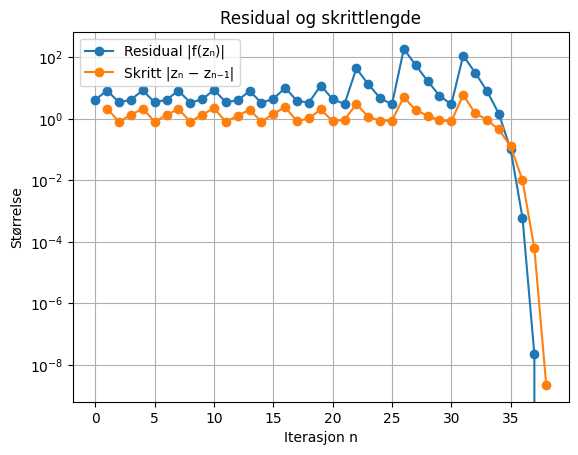

 n                 z_n             |f(z_n)|       skrittlengde
 0                 -0.5-1j   2.775e+00           -
 1  -1.0046189376443-0.82678983833718j   9.864e-01      5.335e-01
 2  -0.98715282968496-1.0198879205725j   1.510e-01      1.939e-01
 3  -0.99962921008158-0.99999119860175j   2.345e-03      2.348e-02
 4  -1.0000000451176-0.9999999194905j   5.837e-07      3.709e-04
 5    -0.99999999999999-1j   3.576e-14      9.229e-08

Stoppårsak: liten residual
Iterasjoner: 5
Nærmeste nullpunkt: (-1.0000000000000004-0.9999999999999996j)


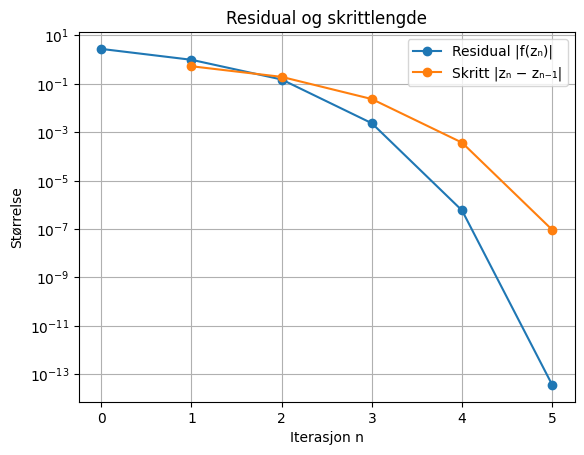

In [ ]:
# Bytt startverdien med en verdi du vil undersøke nærmere.
z0_sakte = 0.1
z0_rask = (-0.5-1j)


result_sakte = newton_trace(f, df, roots, z0_sakte, tol=1e-8, maxiter=50)
print_trace(result_sakte)
plot_trace(result_sakte)

result_rask = newton_trace(f, df, roots, z0_rask, tol=1e-8, maxiter=50)
print_trace(result_rask)
plot_trace(result_rask)

1. Alle startverdiene konvergere, men ikke mote samme nullpunkt
2. Residualen avtar ikke nødvedingvis i hvert eneste steg
3. steglendge: $|x_{n+1} - x_n| = |f(x_n)/f'(x_n)|$

   $g'(r) = f(r)*f''(r)/f'(r)^2$

   residual: $|f(x_n)|$

   dette gir: steglendge = residual/$f'(x_n)$

   Ved en dobbel rot avtar resiudalen raskere enn steglendgen, frodi f'(x_n) selv går mot null når x_n går mot r. Dette betyr at rediusalen ikke avtar i takt, gapet mellom resiudalen og steglenden blir større for hver iterasjon


4. Vi trenger både residualtoleranse og maxiter fordi hvis f er falt nok vil ikke residualen, $f'(r) * e_n$, kunne gi en godt mål på om vi er nærme en rot. Dette kommer av at |f'(r)| kan være liten selv om |e_n| er stor, men dette vil gi en liten residual. Maxiter gir en grense for hvor mange interasjoner vi skal gidde å se på.
5. Hva skjer om vi kommer til et næreme et punkt hvor $f'(r) = 0$.
   Her kan e_n gi en feil formening om hvor nære vi er en løsning. Her blir $x_{x+1} = x_n - f(x_n)/f'(x_n)$. dette blir et stort skritt, så du ender opp i et annent konvergens område eller utenfor et. Dette er grunnen til å sjekke |f'(x_n)|.

## 3.hovedfigur med tiltrekningsområder og iterasjonskart

In [ ]:
def newton_grid(f, df, roots, bounds, nx=500, ny=500,
                tol=1e-8, maxiter=50, derivative_tol=1e-14):
    """Kjør det samme Newton-forsøket for alle pikslene i et rektangel.

    bounds velger delen av det komplekse planet vi ser. nx og ny bestemmer
    bildeoppløsningen, ikke nøyaktigheten til én Newton-iterasjon. Returverdien
    inneholder både funnet nullpunkt, iterasjonstall og sluttresidual.
    """
    xmin, xmax, ymin, ymax = bounds
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)
    z = x[None, :] + 1j*y[:, None]

    basin = np.full(z.shape, -1, dtype=int)
    iterations = np.zeros(z.shape, dtype=int)
    # active forteller hvilke piksler som fortsatt trenger et nytt Newton-skritt.
    active = np.ones(z.shape, dtype=bool)

    for n in range(1, maxiter + 1):
        with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
            derivative = df(z)
            safe = (active & np.isfinite(z.real) & np.isfinite(z.imag)
                    & np.isfinite(derivative.real)
                    & np.isfinite(derivative.imag)
                    & (np.abs(derivative) > derivative_tol))

            # Skill ugyldige beregninger fra dem som bare trenger flere steg.
            invalid = active & ~safe
            basin[invalid] = -2
            iterations[invalid] = n-1
            active[invalid] = False

            z[safe] = z[safe] - f(z[safe])/derivative[safe]
            finite = np.isfinite(z.real) & np.isfinite(z.imag)
            invalid_after = active & ~finite
            basin[invalid_after] = -2
            iterations[invalid_after] = n
            active[invalid_after] = False

            residual = np.full(z.shape, np.inf)
            residual[active] = np.abs(f(z[active]))
            converged = active & (residual < tol)

        if np.any(converged):
            # Først nå bestemmer vi hvilket nullpunkt pikslene endte ved.
            converged_values = z[converged]
            distances = np.abs(converged_values[:, None] - roots[None, :])
            basin[converged] = np.argmin(distances, axis=1)
            iterations[converged] = n
            active[converged] = False

        if not np.any(active):
            break

    iterations[active] = maxiter
    final_residual = np.full(z.shape, np.inf)
    finite = np.isfinite(z.real) & np.isfinite(z.imag)
    with np.errstate(over="ignore", invalid="ignore"):
        final_residual[finite] = np.abs(f(z[finite]))

    return {"basin": basin, "iterations": iterations,
            "residual": final_residual, "z": z,
            "bounds": bounds, "tol": tol, "maxiter": maxiter,
            "roots": roots}


ROOT_COLORS = np.array([
    [0.90, 0.20, 0.20], [0.20, 0.65, 0.95], [0.25, 0.80, 0.35],
    [0.90, 0.65, 0.15], [0.65, 0.35, 0.90], [0.20, 0.80, 0.80],
])


def plot_basins(data, title="Newtons metode: tiltrekningsområder",
                critical_points=None, iteration_cap=20):
    """Vis resultat og arbeidsmengde i hvert sitt panel.

    Venstre panel svarer på hvilket nullpunkt som ble funnet. Høyre panel
    viser antall iterasjoner. iteration_cap bestemmer hvor fargeskalaen
    stopper; større verdier vises fortsatt, men får samme endefarge.
    """
    basin = data["basin"]
    iterations = data["iterations"]
    maxiter = data["maxiter"]
    roots = data["roots"]
    xmin, xmax, ymin, ymax = data["bounds"]

    # Basin-fargen skal bare kode nullpunkt, ikke iterasjonstall.
    basin_image = np.full(basin.shape + (3,), 0.25)
    basin_image[basin == -2] = 0.0
    legend_handles = []
    for k in range(len(roots)):
        mask = basin == k
        color = ROOT_COLORS[k % len(ROOT_COLORS)]
        basin_image[mask] = color
        legend_handles.append(Patch(facecolor=color, label=f"Mot r{k+1}"))

    plt.close("all")
    fig, (ax_basin, ax_iterations) = plt.subplots(
        1, 2, figsize=(13, 6), constrained_layout=True
    )

    ax_basin.imshow(basin_image, origin="lower",
                    extent=(xmin, xmax, ymin, ymax),
                    interpolation="nearest")
    ax_basin.scatter(roots.real, roots.imag, c="white", edgecolors="black",
                     s=70, marker="o")
    for k, root in enumerate(roots):
        ax_basin.annotate(f"r{k+1}", (root.real, root.imag),
                          xytext=(7, 7), textcoords="offset points",
                          color="black", weight="bold")
    if critical_points is not None:
        critical_handle = ax_basin.scatter(
            critical_points.real, critical_points.imag,
            c="black", edgecolors="white", s=70, marker="X",
            linewidths=1.5, label="Kritiske punkter"
        )
        legend_handles.append(critical_handle)

    ax_basin.set_title("Funnet nullpunkt")
    ax_basin.legend(handles=legend_handles, loc="best")

    converged = basin >= 0
    # Avkort skalaen slik at noen få trege piksler ikke vasker ut hele kartet.
    capped_iterations = np.ma.masked_where(
        ~converged, np.minimum(iterations, iteration_cap)
    )
    iteration_image = ax_iterations.imshow(
        capped_iterations, origin="lower", extent=(xmin, xmax, ymin, ymax),
        interpolation="nearest", cmap="viridis",
        vmin=1, vmax=iteration_cap
    )
    ax_iterations.scatter(roots.real, roots.imag, c="white",
                          edgecolors="black", s=45, marker="o")
    colorbar = fig.colorbar(iteration_image, ax=ax_iterations, shrink=0.82)
    colorbar.set_label(
        f"Antall iterasjoner ({iteration_cap} = {iteration_cap} eller flere)"
    )
    ax_iterations.set_title("Iterasjoner før residualkravet er oppfylt")

    for ax in (ax_basin, ax_iterations):
        ax.set_xlabel("Re(z₀)")
        ax.set_ylabel("Im(z₀)")
        ax.set_aspect("equal")

    fig.suptitle(title)
    plt.show()


def summarize_grid(data):
    """Trekk ut noen få tall som gjør ulike rutenett sammenlignbare."""
    basin = data["basin"]
    iterations = data["iterations"]
    residual = data["residual"]
    converged = basin >= 0
    total = basin.size

    summary = {
        "total": total,
        "converged": int(np.count_nonzero(converged)),
        "not_converged": int(np.count_nonzero(basin == -1)),
        "invalid": int(np.count_nonzero(basin == -2)),
        "fraction_converged": float(np.mean(converged)),
        "mean_iterations": (float(np.mean(iterations[converged]))
                            if np.any(converged) else np.nan),
        "max_accepted_residual": (float(np.max(residual[converged]))
                                  if np.any(converged) else np.nan),
    }
    return summary


def print_summary(summary):
    """Skriv sammendraget uten at vi må huske alle nøkkelnavnene."""
    print("Antall startverdier:     ", summary["total"])
    print("Konvergert:              ", summary["converged"])
    print("Nådde maxiter:           ", summary["not_converged"])
    print("Ugyldig beregning:       ", summary["invalid"])
    print("Andel konvergert:        ", f"{summary['fraction_converged']:.4f}")
    print("Gjennomsnitt iterasjoner:", f"{summary['mean_iterations']:.2f}")
    print("Største godkjente residual:",
          f"{summary['max_accepted_residual']:.3e}")


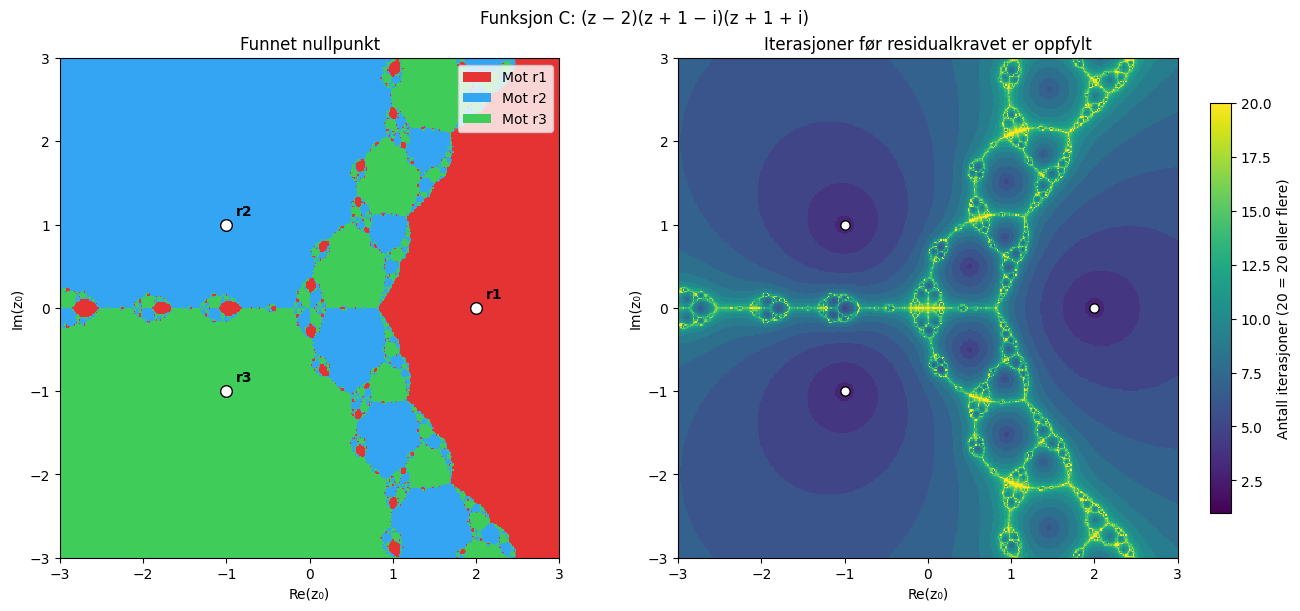

Antall startverdier:      160000
Konvergert:               160000
Nådde maxiter:            0
Ugyldig beregning:        0
Andel konvergert:         1.0000
Gjennomsnitt iterasjoner: 7.24
Største godkjente residual: 9.995e-09


In [ ]:
bounds = my_function["plot_window"]

basin_data = newton_grid(
    f, df, roots,
    bounds=bounds,
    nx=400, ny=400,
    tol=1e-8,
    maxiter=500,
)

plot_basins(basin_data, f"Funksjon {my_function['label']}: {my_function['formula']}")
print_summary(summarize_grid(basin_data))

In [ ]:
def first_start_in(data, mask):
    """Finn én startverdi i en kategori, hvis kategorien finnes."""
    indices = np.argwhere(mask)
    if len(indices) == 0:
        return None
    row, col = indices[len(indices)//2]
    xmin, xmax, ymin, ymax = data["bounds"]
    ny, nx = data["basin"].shape
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)
    return x[col] + 1j*y[row]


converged = basin_data["basin"] >= 0
categories = {
    "rask": converged & (basin_data["iterations"] <= 6),
    "langsom": converged & (basin_data["iterations"] > 15),
    "mislykket": basin_data["basin"] < 0,
}

for name, mask in categories.items():
    print(f"Forslag, {name}:", first_start_in(basin_data, mask))

Forslag, rask: (-1.81203007518797+0.007518796992481036j)
Forslag, langsom: (-3+0.007518796992481036j)
Forslag, mislykket: None


1. Det røde konvergerer mot: r1 = (1+0i)

   Det blå konvergerer mot: r2 = (-1+1j)

   Det grønne konvergerer mot: r3 = (-1-1j)

2. Fra figuren "iterasjoner før residualkravet" kan vi se at det er rundt grensene fra konvergensomårdet til et nullpunkt til et annent (eks: grensen mellom blå og rød område)

3. Områdene langs grensne har trenger flere iterasjoner for å konvergere. Har noe at den må "velge" hvilken rot den skal til.

4. Det er symetrsik om den reele aksen, fordi vi bare har reele koeffisienter, (1,0,-2,-4).

   Dette gir $f(x ̄ ) = conj(f(x))$,

   Oppdatering gir: N(z) = z - f(z)/f'(z),

   For z̄: N(z̄) = z̄ - f(z̄)/f'(z̄)

   => z̄ - conj(f(z))/conj(f'(z)) = conj(z - f(z)/f'(z))
   
   => conj(N(z))

  5. Rutenette er ikke "fint" nok til å konkluedere med ta et hvert punkt vil konvergere.
  
  Suppose every point in B converges to some root. Then B is entirely covered by the open sets A₁, ..., A_k, restricted to B. Now pick a straight line segment inside B connecting a point that converges to r₁ and a point that converges to r₂ (possible since B is a rectangle — convex, so any two points connect via a segment inside it).

   Walk along that segment continuously. At the start, you're "in A₁"; at the end, you're "in A₂." Since these are open sets and they're disjoint (can't converge to two roots at once), there is no way to continuously pass from one to the other while staying only in A₁ ∪ A₂ — you'd need a point on the segment that's in neither, i.e., a point that doesn't converge to either root.

### Proof (GPT): A Fixed Grid Touching Multiple Basins Contains a Non-Converging Point

#### Setup

Let f(z) have k ≥ 2 distinct roots r₁, ..., r_k, and let N(z) = z − f(z)/f'(z) be the Newton map. Define the **basin of attraction** of root rᵢ:

$$A_i = \{z_0 \in \mathbb{C} : N^n(z_0) \to r_i \text{ as } n \to \infty\}$$

Let B ⊂ ℂ be a fixed grid cell — a rectangle (or any connected region), and suppose from the rendered image that B contains points colored for at least two different roots (say some points end up in A₁, others in A₂).

#### Lemma: Each Aᵢ is open

Since rᵢ is a simple root, one can show N'(rᵢ) = 0, so rᵢ is a **superattracting fixed point**. This means there's a small disc U around rᵢ such that N(U) ⊆ U, and every point in U converges to rᵢ under iteration.

Now write:

$$A_i = \bigcup_{n=0}^{\infty} N^{-n}(U)$$

Each N⁻ⁿ(U) is open (N is continuous, so preimages of open sets are open), and a union of open sets is open. So **Aᵢ is open**. ∎

#### Claim: There exists z₀ ∈ B that does not converge to any root

**Proof by contradiction.**

Suppose every point in B converges to *some* root. Then:

$$B = \bigcup_{i=1}^{k} (B \cap A_i)$$

By assumption from the image, B meets at least two of these basins — say B ∩ A₁ ≠ ∅ and B ∩ A₂ ≠ ∅. Since each Aᵢ is open, each B ∩ Aᵢ is open in B (relative topology). The sets B ∩ A₁, ..., B ∩ A_k are also pairwise disjoint (a point can't converge to two different roots).

So we have written B as a **disjoint union of two or more nonempty relatively-open sets**.

But B is a grid cell — a rectangle, hence path-connected, hence connected. By the definition of connectedness, a connected set **cannot** be partitioned into two or more disjoint nonempty open subsets. This is a direct contradiction.

Therefore our assumption was false: **not every point in B converges to a root.**

$$\therefore \exists\, z_0 \in B \text{ such that } N^n(z_0) \not\to r_i \text{ for any } i$$

∎

#### Why this matches the picture

This is exactly the topological seed of the fractal behavior discussed earlier: the leftover points (the ones "not in any Aᵢ") are precisely the Julia set ∩ B. The argument above proves their existence in any grid cell touching two colors — **without needing to invoke fractal dimension, chaos, or density of periodic orbits at all**. Those richer facts (density, self-similarity, uncountability) tell you *how much* structure is hiding in that leftover set, but this simple connectedness argument alone is enough to prove it's **nonempty**.

## 4.Finner vi alltid nærmeste nullpunkt

In [ ]:
def compare_with_nearest(data):
    """Test nærmeste-nullpunkt-gjetningen på hele rutenettet."""
    basin = data["basin"]
    roots = data["roots"]
    xmin, xmax, ymin, ymax = data["bounds"]
    ny, nx = basin.shape
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)
    z0 = x[None, :] + 1j*y[:, None]

    nearest = np.argmin(np.abs(z0[..., None] - roots), axis=2)
    converged = basin >= 0
    different = converged & (basin != nearest)
    fraction = np.count_nonzero(different) / np.count_nonzero(converged)
    return {"nearest": nearest, "different": different,
            "fraction": fraction, "z0": z0}


nearest_test = compare_with_nearest(basin_data)
print("Andel konvergerte startverdier som ikke fant nærmeste nullpunkt:",
      f"{nearest_test['fraction']:.4f}")

indices = np.argwhere(nearest_test["different"])
print("Noen moteksempler:")
for row, col in indices[:5]:
    z0 = nearest_test["z0"][row, col]
    nearest_index = nearest_test["nearest"][row, col]
    found_index = basin_data["basin"][row, col]
    print(f"z₀={z0:.5g}: nærmest {roots[nearest_index]:.5g}, "
          f"men fant {roots[found_index]:.5g}")

Andel konvergerte startverdier som ikke fant nærmeste nullpunkt: 0.1778
Noen moteksempler:
z₀=1.0752-3j: nærmest -1-1j, men fant -1+1j
z₀=1.0902-3j: nærmest -1-1j, men fant -1+1j
z₀=1.1053-3j: nærmest -1-1j, men fant -1+1j
z₀=1.1203-3j: nærmest -1-1j, men fant -1+1j
z₀=1.1353-3j: nærmest -1-1j, men fant -1+1j


1. 17.78% finner ikke næmeste nullpunkt, dette kan også ses på figurene for "basin of attraction"


 n                 z_n             |f(z_n)|       skrittlengde
 0               1.0752-3j   4.077e+01           -
 1  0.65706383272001-1.7980517298775j   1.342e+01      1.273e+00
 2  0.22518305041216-0.82323346426944j   5.320e+00      1.066e+00
 3  -0.79889493984645+0.0059824385523857j   2.912e+00      1.318e+00
 4  -31.441752556448+10.288454011636j   3.616e+04      3.232e+01
 5  -20.972958616025+6.8555054955806j   1.071e+04      1.102e+01
 6  -13.998923145759+4.5656774656421j   3.171e+03      7.340e+00
 7  -9.3563929119791+3.0379940919129j   9.384e+02      4.887e+00
 8  -6.2695704388016+2.0193078729686j   2.775e+02      3.251e+00
 9  -4.2194521605142+1.3430595696414j   8.203e+01      2.159e+00
10  -2.8544341029867+0.90365187629858j   2.437e+01      1.434e+00
11  -1.9260553890673+0.64481674006389j   7.449e+00      9.638e-01
12  -1.2425631589118+0.57817147956949j   2.559e+00      6.867e-01
13  -0.80509594926078+0.92026554676524j   1.200e+00      5.553e-01
14  -1.0292403680165+0.98421177

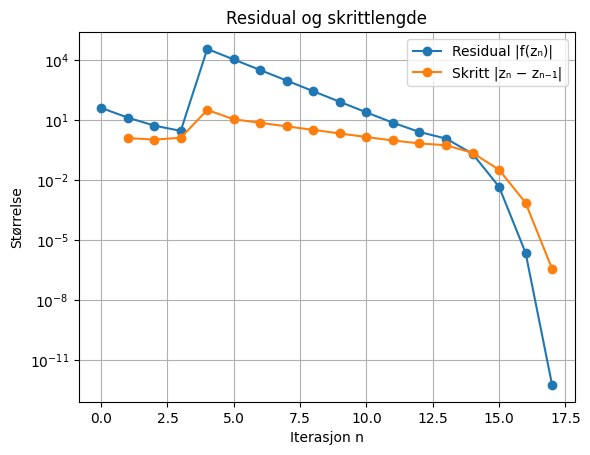

In [ ]:
# 2.
z0_sjekk = (1.0752-3j)


result_sjekk = newton_trace(f, df, roots, z0_sjekk, tol=1e-8, maxiter=50)
print_trace(result_sjekk)
plot_trace(result_sjekk)

3. I fraktalene
4. Vi finner ikke alltid nærmeste rot, fordi oppdaterings regelen benytter den lokale stigningen til z, $z_{n+1} = z- f(z)/f'(z)$.

## 5.Store hopp

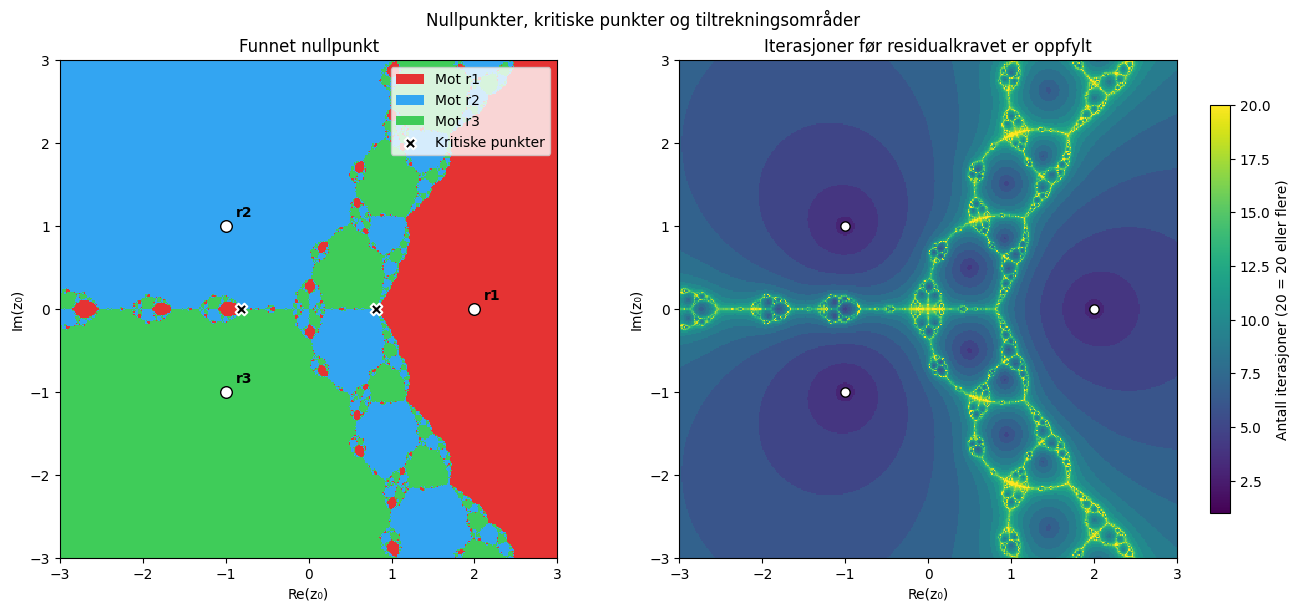

Kritiske punkter:
  (0.8164965809277258+0j)   |f(z)| = 5.088662107903635
  (-0.8164965809277259+0j)   |f(z)| = 2.9113378920963653


In [ ]:
plot_basins(basin_data,
            "Nullpunkter, kritiske punkter og tiltrekningsområder",
            critical_points=critical_points)

print("Kritiske punkter:")
for point in critical_points:
    print(" ", point, "  |f(z)| =", abs(f(point)))

In [ ]:
c = (0.8164965809277258+0j)  # Velg eventuelt et annet kritisk punkt.
critical_starts = [c, c + 1e-3, c + 1e-2j]

for z0 in critical_starts:
    result = newton_trace(f, df, roots, z0, tol=1e-8, maxiter=100)
    steps = [row["step"] for row in result["history"]
             if np.isfinite(row["step"])]
    largest_step = max(steps) if steps else np.nan
    found = roots[result["root"]] if result["converged"] else "ikke funnet"
    print(f"z₀={z0:.8g}: stopp={result['reason']}, "
          f"største skritt={largest_step:.3e}, "
          f"iterasjoner={result['iterations']}, nullpunkt={found}")

z₀=0.81649658+0j: stopp=for liten derivert, største skritt=nan, iterasjoner=0, nullpunkt=ikke funnet
z₀=0.81749658+0j: stopp=liten residual, største skritt=1.038e+03, iterasjoner=21, nullpunkt=(2.0000000000000004+2.220446049250313e-16j)
z₀=0.81649658+0.01j: stopp=liten residual, største skritt=1.039e+02, iterasjoner=17, nullpunkt=(-1.0000000000000004-0.9999999999999996j)


1. Den konvergere ikke, fordi f'(x) = 0 for kritiske punkter
2. Den som ligger nærmest c vil konvergere tregere, de vil også konvergere til forskjellige nullpunkt.
3. Ja, det ligger på grensene mellom de forskjellige konvergens områdene.
4. $|f'(z_0)|$ er ikke nok, steglengden er gitt ved: $f(x_n)/f'(x_n)$. Her vis kun f'(x) er liten vil vi ta et stort steg, og hvis f(x_n) også er liten vil vi ta et lite steg.

## 6.Nær grenser

In [ ]:
def suggest_boundary_point(data):
    """Finn et sentralt sted der to nabopiksler har forskjellig farge."""
    basin = data["basin"]
    left = basin[:, :-1]
    right = basin[:, 1:]
    candidates = np.argwhere((left >= 0) & (right >= 0) & (left != right))
    if len(candidates) == 0:
        raise ValueError("Fant ingen grense mellom to tiltrekningsområder")

    ny, nx = basin.shape
    margin_y = max(1, ny//20)
    margin_x = max(1, nx//20)
    interior = candidates[(candidates[:, 0] >= margin_y)
                          & (candidates[:, 0] < ny-margin_y)
                          & (candidates[:, 1] >= margin_x)
                          & (candidates[:, 1] < nx-margin_x)]
    if len(interior) > 0:
        candidates = interior

    center = np.array([ny/2, nx/2])
    row, col = candidates[np.argmin(np.sum((candidates-center)**2, axis=1))]
    xmin, xmax, ymin, ymax = data["bounds"]
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)
    return (x[col] + x[col+1])/2 + 1j*y[row]


boundary_point = suggest_boundary_point(basin_data)
delta = 1e-3
nearby_starts = [boundary_point,
                 boundary_point + 20*delta,
                 boundary_point + 1j*delta]

print("Foreslått grensepunkt:", boundary_point)
for z0 in nearby_starts:
    result = newton_trace(f, df, roots, z0, tol=1e-8, maxiter=100)
    found = roots[result["root"]] if result["converged"] else "ikke funnet"
    print(f"z₀={z0:.8g}: {result['iterations']} iterasjoner, "
          f"nullpunkt={found}, stopp={result['reason']}")

Foreslått grensepunkt: (-2.220446049250313e-16+0.007518796992481036j)
z₀=-2.220446e-16+0.007518797j: 24 iterasjoner, nullpunkt=(2.0000000000000004+2.220446049250313e-16j), stopp=liten residual
z₀=0.02+0.007518797j: 19 iterasjoner, nullpunkt=(-0.9999999999999991+1.0000000000000002j), stopp=liten residual
z₀=-2.220446e-16+0.008518797j: 22 iterasjoner, nullpunkt=(2.0000000000000004+2.220446049250313e-16j), stopp=liten residual


 n                 z_n             |f(z_n)|       skrittlengde
 0  -2.220446e-16+0.007518797j   4.000e+00           -
 1  -1.9998304174554+4.2501890931343e-07j   7.998e+00      2.000e+00
 2  -1.1998371917832+4.0806313873658e-07j   3.328e+00      8.000e-01
 3  0.2352078312817+1.8180170548821e-06j   4.457e+00      1.435e+00
 4  -2.1951771030541-3.3999237487682e-06j   1.019e+01      2.430e+00
 5  -1.3773031933859-2.9402451152508e-06j   3.858e+00      8.179e-01
 6  -0.33200356502395-6.8813519404635e-06j   3.373e+00      1.045e+00
 7  -2.3523391514978-1.6590193472577e-05j   1.231e+01      2.020e+00
 8  -1.5090810108242-1.3523699060015e-05j   4.419e+00      8.433e-01
 9  -0.59465051891728-2.3173156210318e-05j   3.021e+00      9.144e-01
10  -3.8112838388324-0.00028317475354726j   5.174e+01      3.217e+00
11  -2.5668725561437-0.00019381216791021j   1.578e+01      1.244e+00
12  -1.6787432027638-0.00014921443510101j   5.374e+00      8.881e-01
13  -0.84622608751702-0.00019385387523611j   2.914e+0

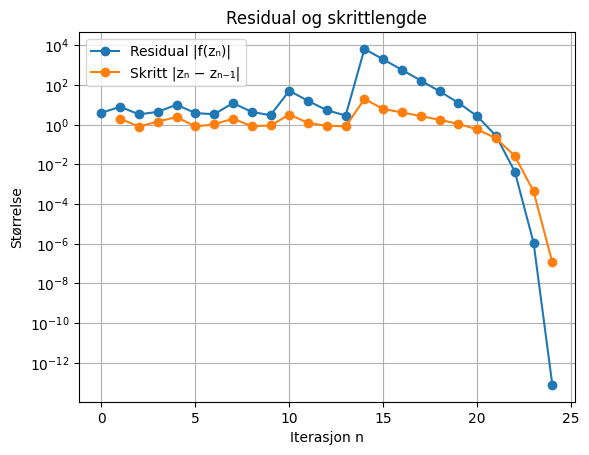

 n                 z_n             |f(z_n)|       skrittlengde
 0       0.02+0.007518797j   4.040e+00           -
 1  -2.0010351331049-0.00091178987433592j   8.010e+00      2.021e+00
 2  -1.2009936524362-0.00087472995535723j   3.330e+00      8.000e-01
 3  0.2300615222441-0.003876117841706j   4.448e+00      1.431e+00
 4  -2.1856201099302+0.0070196076484562j   1.007e+01      2.416e+00
 5  -1.3690304756827+0.006096104194932j   3.828e+00      8.166e-01
 6  -0.31254201318973+0.014603427047619j   3.405e+00      1.057e+00
 7  -2.3064430946767+0.031980364739079j   1.166e+01      1.994e+00
 8  -1.4715306635717+0.026471672604649j   4.242e+00      8.349e-01
 9  -0.52917715448367+0.049000374946678j   3.087e+00      9.426e-01
10  -3.1335405537073+0.34736878755041j   2.897e+01      2.621e+00
11  -2.0991316126936+0.24623733212041j   9.094e+00      1.039e+00
12  -1.3063030143045+0.22006971102634j   3.493e+00      7.933e-01
13  -0.34548422906575+0.55009175787681j   3.220e+00      1.016e+00
14  -1.49429

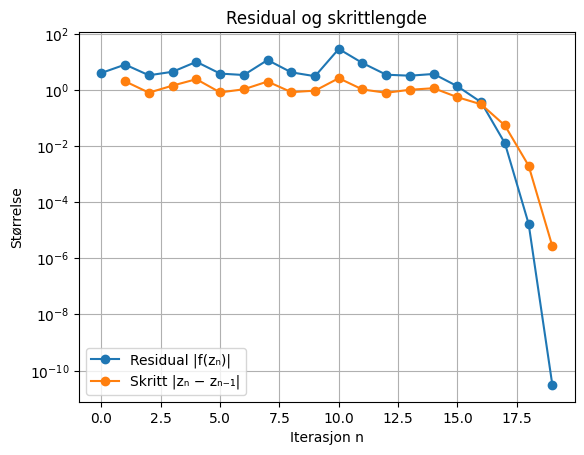

In [ ]:
z0_1 = (-2.220446e-16+0.007518797j)
z0_2 = (0.02+0.007518797j)


result_1 = newton_trace(f, df, roots, z0_1, tol=1e-8, maxiter=50)
print_trace(result_1)
plot_trace(result_1)

result_2 = newton_trace(f, df, roots, z0_2, tol=1e-8, maxiter=50)
print_trace(result_2)
plot_trace(result_2)

In [ ]:
# 1.
avstand = abs(z0_2 - z0_1)
print(avstand)

0.020000000000000222


2. rundt iterasjon 13-14
3. De fant forkjellige nullpunkt selv om avstanden mellom punktene var liten
4. Inne i et konvegens område er forksjellen vare antall iterasojner, men de finner samme nullpunkt.

## 7.Kontroll stopp kriterier

In [ ]:
print("      tol  maxiter  konvergert  nådde grensen  gj.snitt steg")
for tolerance, maximum in [(1e-4, 50), (1e-8, 50),
                           (1e-12, 50), (1e-8, 15), (1e-8, 100)]:
    data = newton_grid(f, df, roots, bounds, nx=250, ny=250,
                       tol=tolerance, maxiter=maximum)
    summary = summarize_grid(data)
    print(f"{tolerance:9.0e}  {maximum:7d}  {summary['converged']:10d}  "
          f"{summary['not_converged']:13d}  "
          f"{summary['mean_iterations']:13.2f}")

      tol  maxiter  konvergert  nådde grensen  gj.snitt steg
    1e-04       50       62500              0           6.40
    1e-08       50       62500              0           7.24
    1e-12       50       62500              0           7.78
    1e-08       15       61360           1140           7.03
    1e-08      100       62500              0           7.24


1. At vi når maxiter betyr ikke nødvendig hvis at vi divergerer. Vi bare kutter av før vi får eventualet konvergert.
2. Nei, $|f(z_n)|<10^{-12}$ betyr ikke nødveding hvis at $|z_n - r| < 10^{12}$. $|z_n - r| ≈ f(z_n)/f'(r)$, dette funker dårlig når f'(r) er liten.

## 8.Hovedproblem

In [ ]:
def boundary_mask(data):
    """Marker piksler ved en overgang mellom to konvergensområder.

    Vi teller bare overganger mellom punkter som faktisk konvergerte. Punkter
    som nådde maxiter eller ga en ugyldig beregning får ikke lage en kunstig
    basin-grense.
    """
    basin = data["basin"]
    boundary = np.zeros(basin.shape, dtype=bool)

    # Sammenlign naboer mot venstre og høyre.
    valid_horizontal = (basin[:, :-1] >= 0) & (basin[:, 1:] >= 0)
    changes_horizontal = valid_horizontal & (basin[:, :-1] != basin[:, 1:])
    boundary[:, :-1] |= changes_horizontal
    boundary[:, 1:] |= changes_horizontal

    # Gjør samme sammenligning opp og ned.
    valid_vertical = (basin[:-1, :] >= 0) & (basin[1:, :] >= 0)
    changes_vertical = valid_vertical & (basin[:-1, :] != basin[1:, :])
    boundary[:-1, :] |= changes_vertical
    boundary[1:, :] |= changes_vertical
    return boundary


def boundary_summary(data):
    """Sammenlign Newton-arbeidet på grensen og inne i basinene."""
    boundary = boundary_mask(data)
    converged = data["basin"] >= 0
    interior = converged & ~boundary
    iterations = data["iterations"]

    return {
        "boundary_fraction": np.count_nonzero(boundary)
                             / np.count_nonzero(converged),
        "mean_boundary_iterations": np.mean(iterations[boundary]),
        "mean_interior_iterations": np.mean(iterations[interior]),
        "max_boundary_iterations": np.max(iterations[boundary]),
        "visible_basins": len(np.unique(data["basin"][converged])),
    }


def print_boundary_summary(data):
    """Skriv de samme målene for hvert zoomnivå."""
    summary = boundary_summary(data)
    xmin, xmax, ymin, ymax = data["bounds"]
    pixel_width = (xmax-xmin)/(data["basin"].shape[1]-1)

    print("Bredde på vinduet:       ", f"{xmax-xmin:.4e}")
    print("Bredde per piksel:       ", f"{pixel_width:.4e}")
    print("Synlige basin:           ", summary["visible_basins"])
    print("Andel grensepiksler:     ", f"{summary['boundary_fraction']:.4f}")
    print("Gj.snitt steg, grense:   ",
          f"{summary['mean_boundary_iterations']:.2f}")
    print("Gj.snitt steg, indre:    ",
          f"{summary['mean_interior_iterations']:.2f}")
    print("Største steg, grense:    ", summary["max_boundary_iterations"])

print_boundary_summary(basin_data) # før zoom

Bredde på vinduet:        6.0000e+00
Bredde per piksel:        1.5038e-02
Synlige basin:            3
Andel grensepiksler:      0.0554
Gj.snitt steg, grense:    14.74
Gj.snitt steg, indre:     6.80
Største steg, grense:     41


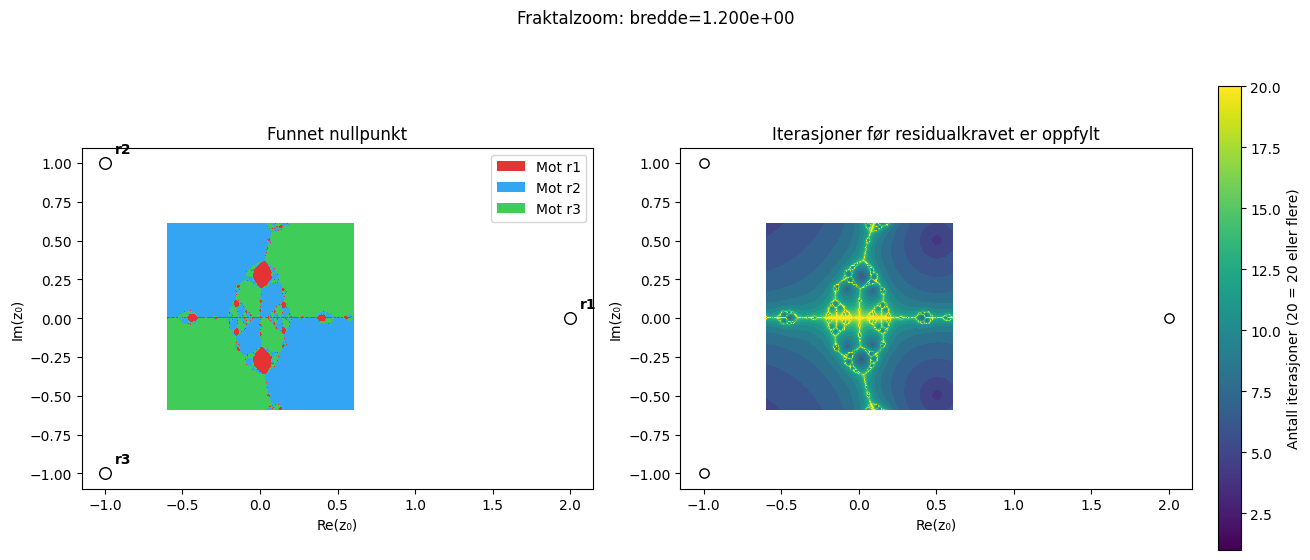

Bredde på vinduet:        1.2000e+00
Bredde per piksel:        3.0075e-03
Synlige basin:            3
Andel grensepiksler:      0.0565
Gj.snitt steg, grense:    17.98
Gj.snitt steg, indre:     8.30
Største steg, grense:     88


In [ ]:
def square_bounds(center, width):
    """Lag et kvadratisk vindu rundt startverdien vi vil følge."""
    half = width/2
    return (center.real-half, center.real+half,
            center.imag-half, center.imag+half)


def run_zoom(center, width, resolution=400, tol=1e-8, maxiter=100):
    """Beregn og vis ett nytt nivå i fraktalzoomen.

    Behold resolution, tol og maxiter når du sammenligner nivåene. Endre
    center og width for å følge grensen videre.
    """
    zoom_bounds = square_bounds(center, width)
    data = newton_grid(
        f, df, roots, zoom_bounds,
        nx=resolution, ny=resolution, tol=tol, maxiter=maxiter
    )
    plot_basins(data, f"Fraktalzoom: bredde={width:.3e}")
    print_boundary_summary(data)
    return data


# Dette er nivå 1. Endre sentrum hvis grensen forsvinner ut av bildet.
zoom_center = (-2.220446e-16+0.007518797j)
zoom_width = min(bounds[1]-bounds[0], bounds[3]-bounds[2]) / 5
zoom_data = run_zoom(zoom_center, zoom_width)

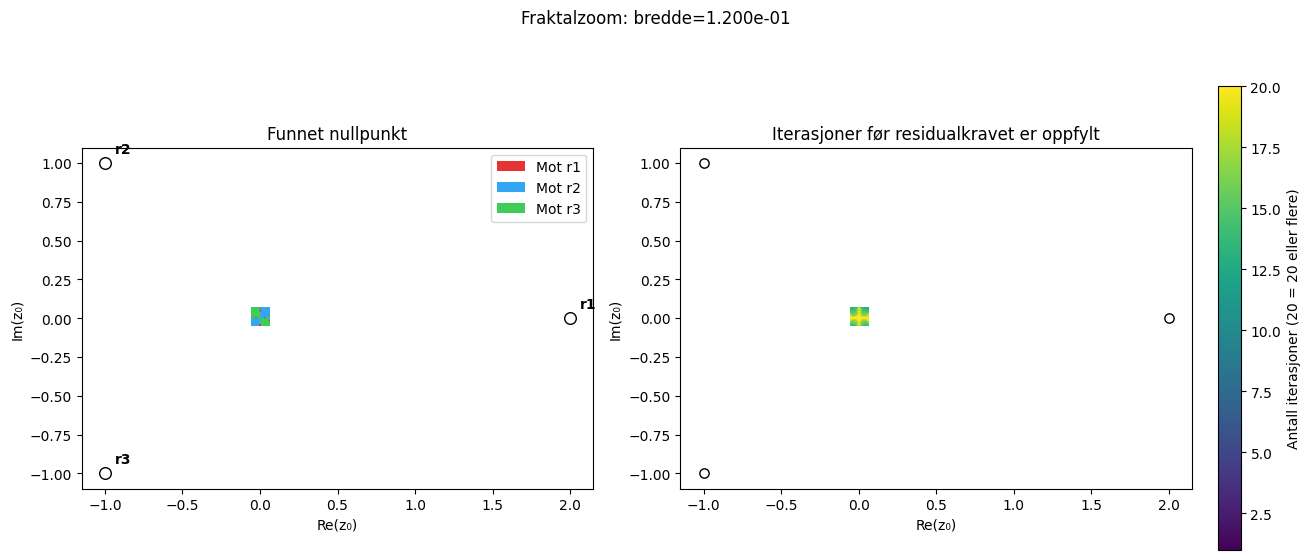

Bredde på vinduet:        1.2000e-01
Bredde per piksel:        3.0075e-04
Synlige basin:            3
Andel grensepiksler:      0.0524
Gj.snitt steg, grense:    25.46
Gj.snitt steg, indre:     16.75
Største steg, grense:     50


In [ ]:
zoom_center = suggest_boundary_point(zoom_data)
zoom_width = zoom_width / 10
zoom_data = run_zoom(zoom_center, zoom_width) # 10x mindre

 n                 z_n             |f(z_n)|       skrittlengde
 0  0.0030075187969922+0.0090225563984963j   4.006e+00           -
 1  -1.9997822190717-0.0001622880406275j   7.998e+00      2.003e+00
 2  -1.1997909237304-0.00015581857857419j   3.328e+00      8.000e-01
 3  0.23541373548088-0.00069435854629914j   4.458e+00      1.435e+00
 4  -2.1955596175556+0.0013001951584403j   1.019e+01      2.431e+00
 5  -1.3776342820982+0.0011242173592047j   3.859e+00      8.179e-01
 6  -0.33278221350997+0.0026286779054889j   3.371e+00      1.045e+00
 7  -2.354178968137+0.0063615178340607j   1.234e+01      2.021e+00
 8  -1.5105856114675+0.0051825748433982j   4.426e+00      8.436e-01
 9  -0.59727034896955+0.0088535845109339j   3.018e+00      9.133e-01
10  -3.8392357360506+0.11059975374018j   5.298e+01      3.244e+00
11  -2.586131592096+0.075620030159691j   1.614e+01      1.254e+00
12  -1.6940012064439+0.057956383817227j   5.470e+00      8.923e-01
13  -0.86857309788335+0.073625758412008j   2.904e+00    

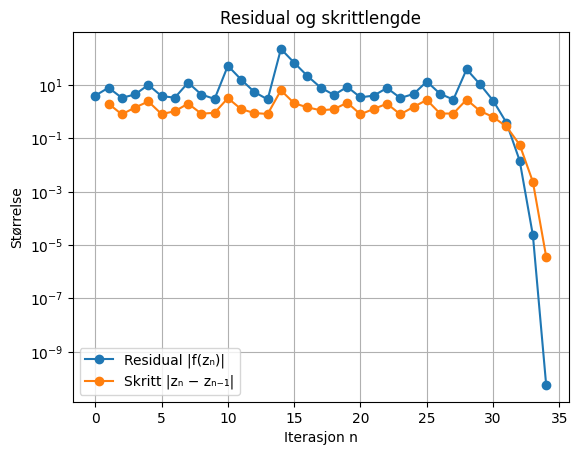

 n                 z_n             |f(z_n)|       skrittlengde
 0  0.0033082687969922+0.0090225563984963j   4.007e+00           -
 1  -1.9997878490473-0.00017861812565888j   7.998e+00      2.003e+00
 2  -1.1997963310002-0.00017149705176768j   3.328e+00      8.000e-01
 3  0.23538958641907-0.00076420557646069j   4.458e+00      1.435e+00
 4  -2.1955138104354+0.0014307697017154j   1.019e+01      2.431e+00
 5  -1.3775947417245+0.0012371436433637j   3.859e+00      8.179e-01
 6  -0.33269062538311+0.0028930429494629j   3.371e+00      1.045e+00
 7  -2.3539487245532+0.0069981054909371j   1.234e+01      2.021e+00
 8  -1.5103991458914+0.0057016035089659j   4.425e+00      8.436e-01
 9  -0.59696135027727+0.0097437837246022j   3.019e+00      9.134e-01
10  -3.8344608640144+0.12133908036869j   5.279e+01      3.239e+00
11  -2.582895208664+0.082974302087464j   1.608e+01      1.252e+00
12  -1.6916163502933+0.063631055667931j   5.453e+00      8.915e-01
13  -0.86611500757551+0.081037518716203j   2.900e+00  

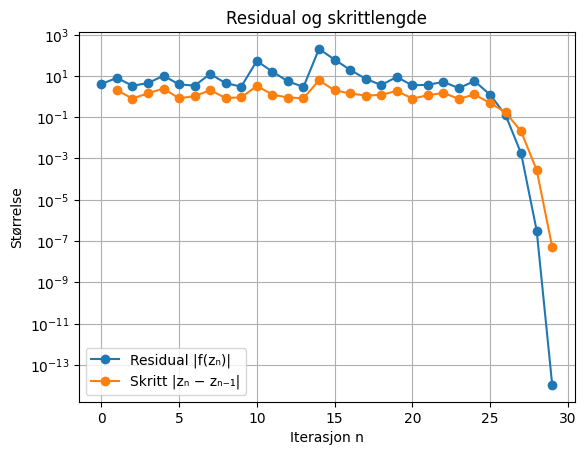

 n                 z_n             |f(z_n)|       skrittlengde
 0                0.1+0.1j   4.207e+00           -
 1  -1.9961434708762-0.061884304126286j   7.962e+00      2.102e+00
 2  -1.1974969885257-0.059490049405959j   3.312e+00      7.987e-01
 3  0.2090184495208-0.2621881887139j   4.481e+00      1.421e+00
 4  -1.8459751436135+0.30824662093473j   6.569e+00      2.133e+00
 5  -1.0858601901265+0.31954936885898j   2.814e+00      7.602e-01
 6  -0.33848500233623+1.211034293288j   4.220e+00      1.163e+00
 7  -0.82161474449425+0.78276072876826j   1.475e+00      6.456e-01
 8  -1.0590030025308+1.0343369832029j   4.486e-01      3.459e-01
 9  -1.0029864631272+0.99996122995512j   1.891e-02      6.572e-02
10  -1.0000025484102+0.99999459080586j   3.782e-05      2.984e-03
11  -0.99999999997663+1.0000000000054j   1.517e-10      5.979e-06

Stoppårsak: liten residual
Iterasjoner: 11
Nærmeste nullpunkt: (-0.9999999999999991+1.0000000000000002j)


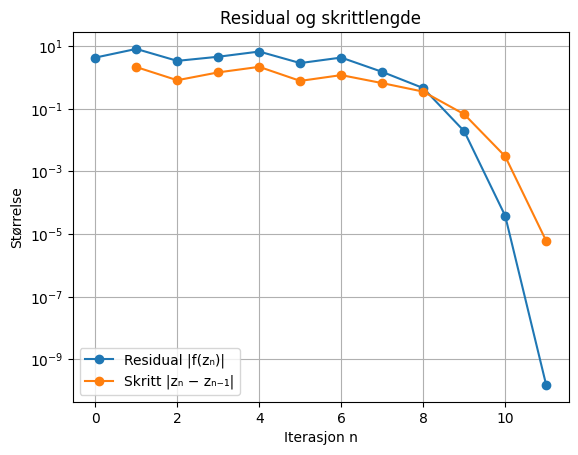

In [ ]:
# for delproblem 4, vi er på siste zoom nivå og zoom_center er på et sentralt sted mellom to nabopunkter
result_1 = newton_trace(f, df, roots, zoom_center, tol=1e-8, maxiter=50)
print_trace(result_1)
plot_trace(result_1)

result_2 = newton_trace(f, df, roots, zoom_center +3.0075e-04, tol=1e-8, maxiter=50) # gå 1 pixel til høyre
print_trace(result_2)
plot_trace(result_2)

result_3 = newton_trace(f, df, roots, (0.1+0.1j), tol=1e-8, maxiter=50) # les av og finn punkt i en basin
print_trace(result_3)
plot_trace(result_3)


1. Forventet å se noe fraktal aktig struktur, dette ble visst på bildene (eks null zoom til zoom 1, osv).
2. Det samme mønstert dukket opp når vi zoomet inn mere. Men det ble mindre grensepiksler, og Gj.snitt steg, grense Gj.snitt steg, indre gikk opp
3. Mønstert kommer an på hvilket punkt du zoomer in fra, men du kan finne gjentakelser eller nye struktuterer fra regelene som danner basinene.
4. En endring i z0 representerer en størrelsen på 1 pixel. Dette tilsaverer 3.0075e-04 (bredde per pixel)
5. Ja, hvis vi var ved en grense fant de forksjellige nullpunkt.
6. tregere konvergens ved grensene enn i de indre områdene.
7. De bruker forkjellige z0, og bruker forksjellig mengde iterasojner på å konvergere.
8. Maxiter bestper hvor mange iterasjoner du sjekker hvert startpunkt (z0). Tol bestemmer hvor små forskjeller vi mener er betydnigsfull. Flytall representasjonen representer hvor nøyaktig tallene og bregrensingene faktisk kan være.
9. Flere vellykkede zoomnivåer er god numerisk evidens for en fraktallignde grense fordi vi ser samme type struktur på midnre skalerer. Men det er ikke bevis for alle skalerer fordi det ikke kan visse om det gjelder for andre skalere.



## 9 Konklusjon

Startverdien til newtons metode påvirker hvilket nullpunkt det finner. Dette er fordi de forskjellige startpunktene ligger i forksjellige tiltrekningsomårder. De der hvert område hører til et nullpunkt.

Konvergensen er rask nær nullpunktet, og blir gradvis mer krevende jo lenger fra nullpunktet man kommer. Det kreves flest iterasjoner langs grensene mellom konvergens områdene, fordi den må "velge" hviklet nullpunkt den skal finne.

Metoden sikkrer ikke alltid at du finner nærmeste nullpunkt. Hvis de er godt i et område finner du nullpunktet som tilhører område (nærmeste), men i noen tilfeller kan startpunktet hver nærmerne et nullpunkt i et annent område. Metoden henviser ikke til distanten til nullpunket, fordi den ikke vet distansen til det.

Hvis vi starter i et kritsikpunkt (f' = 0) konvergerer vi ikke til et nullpunkt. Perturbasjonsforsøket viser at små endringer nær grenser har stor påvirkning på hvor mange iterasjoner det tar før vi konvergere og hvilket nullpunkt vi konvergerer til.

Fraktralzoom viste at følsomheten for startverdi ikke avtar med økende presision. Den forblir følsom på alle skaler, grenseområdene forblir på alle skaler. Så det vil alltid være langs grensen punkte som sender punktet til andre nullpunkter finnes.

Både maxiter og tol er stoppbetingelser. En for høy (løs) tol vil fjerne fine
detaljer og gi feilklassifisering, fordi iterasjonen stopper for tidlig. En for
lav (stram) tol vil avsløre mer struktur, men vil gi feil nær maskinepsilon. For lav maxiter stopper før vi får sett nøye. Dette gir et grovt bilde, mens en høyere maxiter gir et skarpere bilde. Stopper ofte via tol hvis maxiter er satt høy nok.

Vi kan visse at:

- To punkter z og z + ϵ konvergere til forskjellige punkter nær grenser.

- At samme typer struktur dukker opp når vi zoomer inn.

- At bilde viser konvergersing områder, i alle tilfeller (zoom)

Vi kan ikke bevise at:

- Vi alltid kommer til å konvergere

- Om det faktisk er fraktal struktur

Det vil være forsvarlig å si at metoden har konvergert når både residualen og step size er liten. Det er brukt få antall iterasojner og resultatet er robust (for endring Δz).  
